In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

#### Generar datos sintéticos multivariados

In [6]:
np.random.seed(42)
n = 500

MedInc = np.random.lognormal(mean=2.5, sigma=0.35, size=n)
HouseAge = np.random.randint(1, 52, size=n)

Longitude = -118 + np.random.randn(n) * 0.2
Latitude = 34 + np.random.randn(n) * 0.2

AveRooms = np.random.normal(5 + MedInc * 0.5, 1)

target = (
    MedInc * 15
    + HouseAge * 0.3
    + (Latitude - 34) * 50
    + (Longitude + 118) * 50
    + AveRooms * 2
    + np.random.randn(n) * 5
)

data = pd.DataFrame({
    "MedInc": MedInc,
    "HouseAge": HouseAge,
    "Longitude": Longitude,
    "Latitude": Latitude,
    "AveRooms": AveRooms,
    "target": target
})

data.head()

,MedInc,HouseAge,Longitude,Latitude,AveRooms,target
0,14.495670,26,-118.025539,34.173689,11.859261,255.525061
1,11.606990,34,-117.888971,33.640794,9.918679,195.064199
2,15.282234,45,-118.350957,34.262242,12.292132,271.228155
3,20.760672,6,-118.024779,34.138881,15.025252,361.137758
4,11.223910,37,-118.246392,33.934633,10.534421,181.690440


In [7]:
cov_matrix = data.cov()
cov_matrix

,MedInc,HouseAge,Longitude,Latitude,AveRooms,target
MedInc,22.967083,-3.195884,0.031116,-0.010837,11.612808,369.129535
HouseAge,-3.195884,222.304108,-0.122511,-0.075294,-2.170182,6.354546
Longitude,0.031116,-0.122511,0.045626,0.000188,0.012011,2.763054
Latitude,-0.010837,-0.075294,0.000188,0.036225,-0.010687,1.617438
AveRooms,11.612808,-2.170182,0.012011,-0.010687,6.875068,188.104398
target,369.129535,6.354546,2.763054,1.617438,188.104398,6182.156701


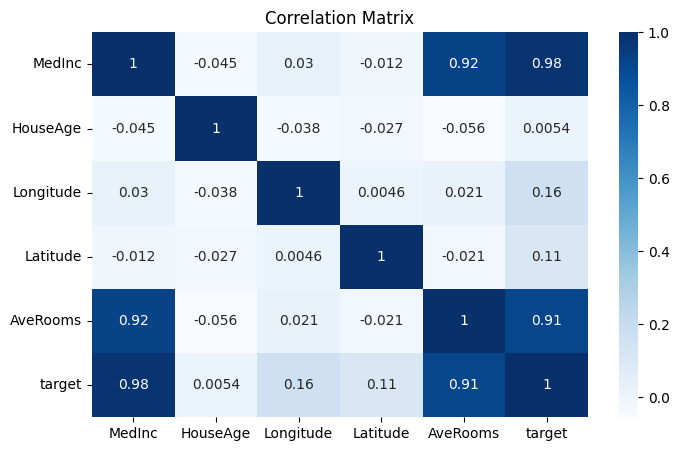

In [8]:
corr_matrix = data.corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

Cálculo matricial del modelo lineal

In [9]:
X = data[["MedInc", "HouseAge", "Longitude", "Latitude", "AveRooms"]].values
y = data["target"].values.reshape(-1, 1)

X = np.hstack([np.ones((X.shape[0], 1)), X])

XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y

y_hat = X @ beta
residuals = y - y_hat

beta

array([[4.24055493e+03],
       [1.50211824e+01],
       [3.09545774e-01],
       [5.03930677e+01],
       [5.01376884e+01],
       [2.07541330e+00]])

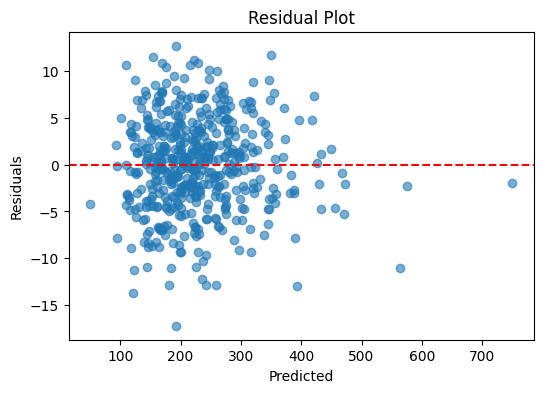

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(y_hat, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#### Calcular la Hat Matrix y Leverage

In [11]:
H = X @ XtX_inv @ X.T
leverage = np.diag(H)

df_leverage = pd.DataFrame({
    "Predicted": y_hat.flatten(),
    "Residuals": residuals.flatten(),
    "Leverage": leverage
})

df_leverage.head()

,Predicted,Residuals,Leverage
0,256.678854,-1.153793,0.004411
1,191.900320,3.163879,0.011882
2,263.314780,7.913375,0.016078
3,349.459584,11.678175,0.012311
4,185.073424,-3.382984,0.006483


In [12]:
n, p = X.shape
threshold = 2*p/n
threshold

0.024

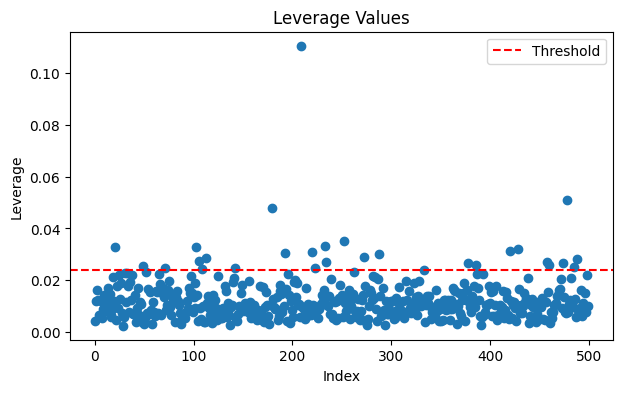

In [13]:
plt.figure(figsize=(7,4))
plt.scatter(range(n), leverage)
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Leverage Values")
plt.xlabel("Index")
plt.ylabel("Leverage")
plt.legend()
plt.show()

In [14]:
df_leverage.sort_values("Leverage", ascending=False).head(10)

,Predicted,Residuals,Leverage
209,750.118917,-1.950909,0.110441
478,574.634742,-2.303608,0.050798
179,564.201826,-11.037580,0.048041
252,470.671026,-5.300749,0.035006
233,144.148974,0.715032,0.033070
21,234.691997,3.421489,0.032903
103,200.058593,-3.036622,0.032861
428,316.736845,-9.354452,0.032057
420,425.817674,0.148394,0.031255
220,466.983230,-0.907455,0.030816


In [15]:
summary = pd.DataFrame({
    "index": np.arange(n),
    "leverage": leverage,
    "y": y.flatten(),
    "y_hat": y_hat.flatten(),
    "resid": residuals.flatten()
})

print("Top Ten Leverage Points:")
summary.sort_values(by="leverage", ascending=False).head(10)

Top Ten Leverage Points:


,index,leverage,y,y_hat,resid
209,209,0.110441,748.168009,750.118917,-1.950909
478,478,0.050798,572.331134,574.634742,-2.303608
179,179,0.048041,553.164246,564.201826,-11.037580
252,252,0.035006,465.370277,470.671026,-5.300749
233,233,0.033070,144.864006,144.148974,0.715032
21,21,0.032903,238.113486,234.691997,3.421489
103,103,0.032861,197.021970,200.058593,-3.036622
428,428,0.032057,307.382393,316.736845,-9.354452
420,420,0.031255,425.966067,425.817674,0.148394
220,220,0.030816,466.075775,466.983230,-0.907455


In [16]:
n, p = X.shape
avg_lev = p/n
threshold = 2 * avg_lev

avg_lev, threshold

(0.012, 0.024)

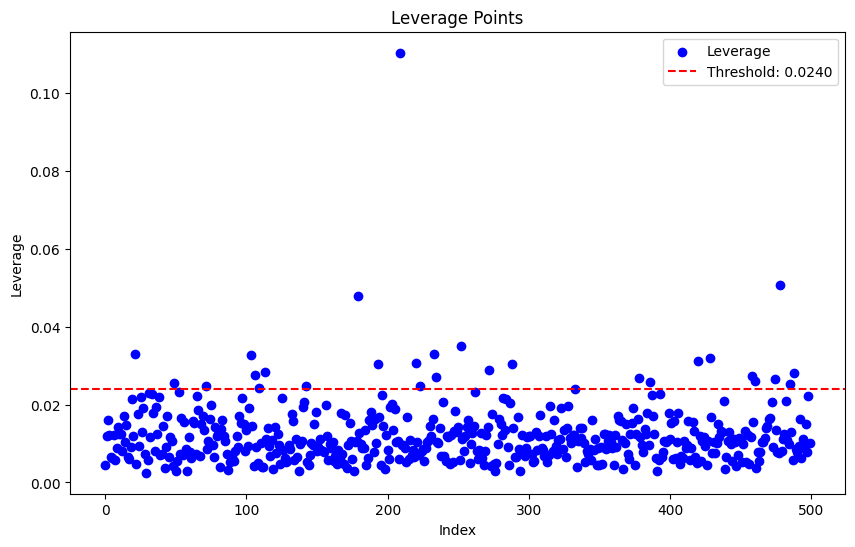

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(summary["index"], summary["leverage"], c='blue', label='Leverage')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.xlabel('Index')
plt.ylabel('Leverage')
plt.title('Leverage Points')
plt.legend()
plt.show()

La gráfica muestra los valores de leverage (apalancamiento) de cada observación del modelo. La línea roja representa el umbral a partir del cual un punto se considera de alto apalancamiento. En este caso, casi todas las observaciones tienen valores bajos y están por debajo del umbral, excepto unos pocos puntos aislados, que se elevan claramente por encima de la línea. Esos puntos son observaciones influyentes, porque tienen combinaciones inusuales de variables que pueden afectar de manera desproporcionada los coeficientes del modelo y deben analizarse con mayor detalle.

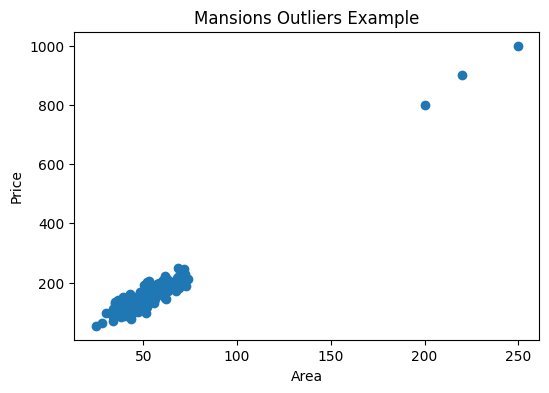

In [18]:
np.random.seed(0)
size = 200

x = np.random.normal(50, 10, size)
y = 3*x + np.random.normal(0, 20, size)

x_out = np.append(x, [200, 220, 250])
y_out = np.append(y, [800, 900, 1000])

plt.figure(figsize=(6,4))
plt.scatter(x_out, y_out)
plt.title("Mansions Outliers Example")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [19]:
import statsmodels.api as sm

house_size = np.random.normal(2000, 300, 100)
house_price = 100000 + 150*house_size + np.random.normal(0, 20000, 100)

# Agregar mansiones (outliers enormes)
house_size = np.append(house_size, [5000, 6000, 7000])
house_price = np.append(house_price, [900000, 1000000, 1500000])

# Modelo OLS
X_m = sm.add_constant(house_size)
model = sm.OLS(house_price, X_m).fit()

# Leverage
influence = model.get_influence()
leverage_m = influence.hat_matrix_diag

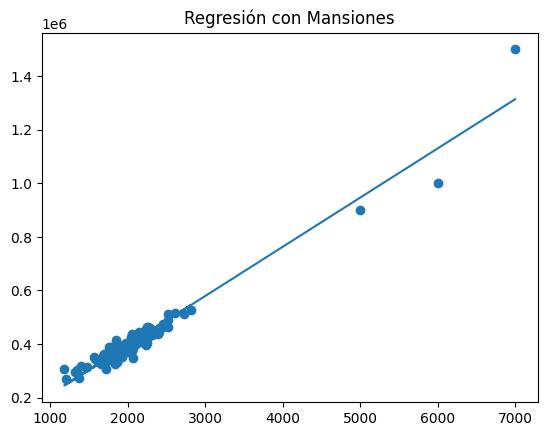

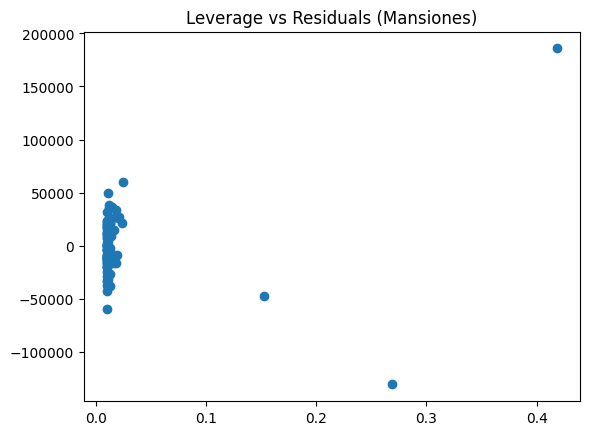

In [20]:
plt.scatter(house_size, house_price)
plt.plot(house_size, model.predict(X_m))
plt.title("Regresión con Mansiones")
plt.show()

plt.scatter(leverage_m, model.resid)
plt.title("Leverage vs Residuals (Mansiones)")
plt.show()

Las gráficas muestran que la mayoría de las observaciones tienen bajo leverage y residuos pequeños, lo que significa que siguen bien el patrón general del modelo. Sin embargo, aparecen varios puntos aislados con leverage muy alto y residuos grandes (positivos o negativos). Esos puntos corresponden a propiedades extremas (mansiones) que se alejan mucho del resto de los datos y, por lo tanto, tienen una influencia desproporcionada sobre la regresión. Estos outliers pueden distorsionar la pendiente, la predicción y la estabilidad del modelo, por lo que deben analizarse o tratarse de manera especial.

## Dataset Real: Boston Housing

In [21]:
# Cargar dataset Boston Housing
raw_df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")
df_boston = raw_df.copy()

df_boston.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [22]:
import seaborn as sns
diamonds = sns.load_dataset("diamonds")

numeric_cols_diamonds = ["carat", "depth", "table", "x", "y", "z"]
target_col_diamonds = "price"

X_d = diamonds[numeric_cols_diamonds].values
y_d = diamonds[target_col_diamonds].values.reshape(-1, 1)

In [23]:
df_boston.rename(columns={"medv": "target"}, inplace=True)

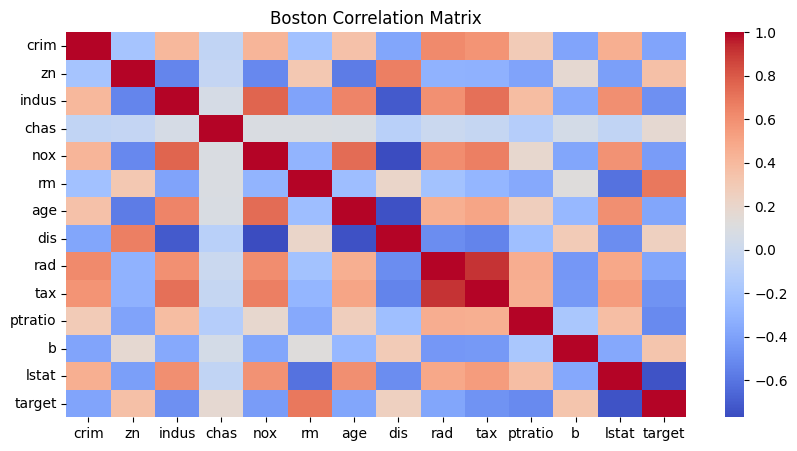

In [24]:
cov_boston = df_boston.cov()
corr_boston = df_boston.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr_boston, cmap="coolwarm")
plt.title("Boston Correlation Matrix")
plt.show()

In [25]:
X = df_boston.drop("target", axis=1).values
X = np.hstack([np.ones((X.shape[0], 1)), X])

y = df_boston["target"].values.reshape(-1, 1)

beta = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta
residuals = y - y_hat

beta

array([[ 3.64594884e+01],
       [-1.08011358e-01],
       [ 4.64204584e-02],
       [ 2.05586264e-02],
       [ 2.68673382e+00],
       [-1.77666112e+01],
       [ 3.80986521e+00],
       [ 6.92224640e-04],
       [-1.47556685e+00],
       [ 3.06049479e-01],
       [-1.23345939e-02],
       [-9.52747232e-01],
       [ 9.31168327e-03],
       [-5.24758378e-01]])

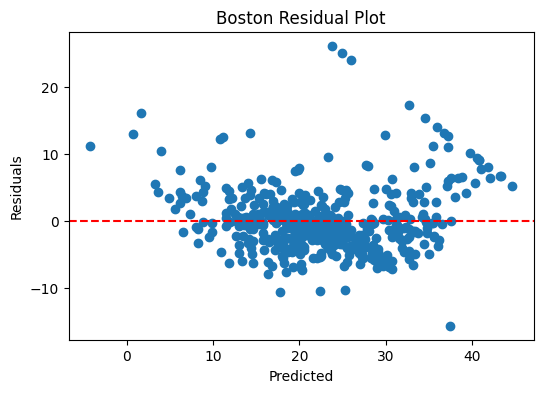

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(y_hat, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Boston Residual Plot")
plt.show()

In [27]:
H = X @ np.linalg.inv(X.T @ X) @ X.T
leverage = np.diag(H)

len(leverage)

506

In [28]:
df_lev = pd.DataFrame({
    "Predicted": y_hat.flatten(),
    "Residuals": residuals.flatten(),
    "Leverage": leverage
})

df_lev.sort_values("Leverage", ascending=False).head(10)

,Predicted,Residuals,Leverage
380,14.369948,-3.969948,0.305959
418,6.147799,2.652201,0.190101
405,8.211159,-3.211159,0.156433
410,15.223083,-0.223083,0.124707
365,14.281907,13.218093,0.098515
155,20.103759,-4.503759,0.085277
490,3.663997,4.436003,0.082067
367,10.831623,12.268377,0.080430
492,15.931185,4.168815,0.077113
364,37.494474,-15.594474,0.076723


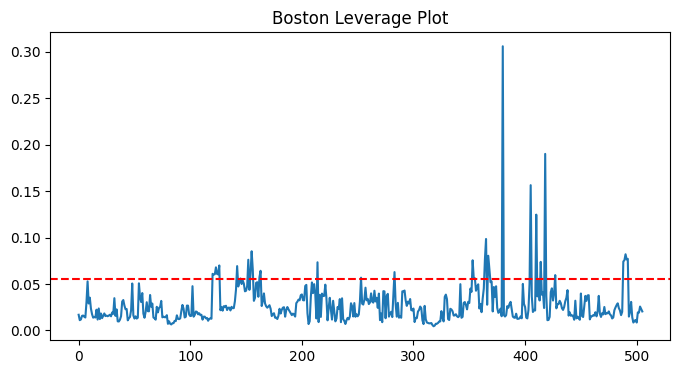

In [29]:
threshold = 2 * X.shape[1] / X.shape[0]

plt.figure(figsize=(8,4))
plt.plot(leverage)
plt.axhline(threshold, color="red", linestyle="--")
plt.title("Boston Leverage Plot")
plt.show()

In [30]:
X = X_d
X = np.hstack([np.ones((X.shape[0], 1)), X])

y = y_d

beta_d = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat_d = X @ beta_d
residuals_d = y - y_hat_d

beta_d

array([[20849.31641312],
       [10686.30908064],
       [ -203.1540524 ],
       [ -102.44565213],
       [-1315.66784181],
       [   66.32160232],
       [   41.62769702]])

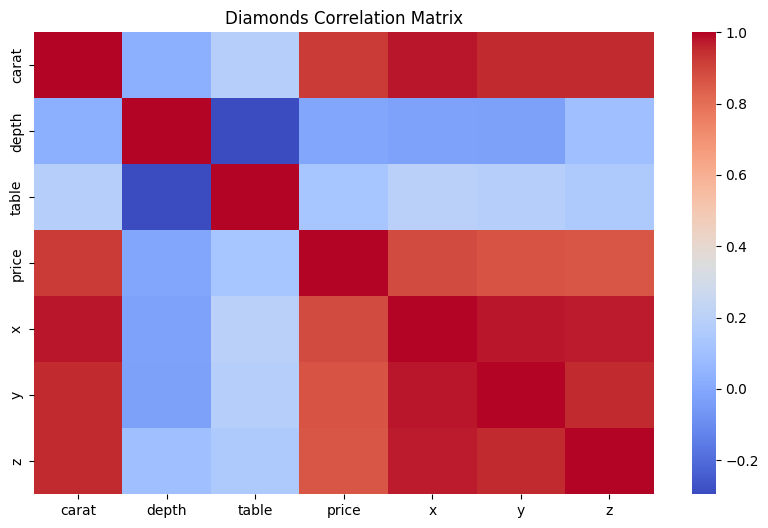

In [32]:
# Seleccionar solo columnas numéricas
diamonds_numeric = diamonds.select_dtypes(include=["float64", "int64"])

# Matriz de correlación solo con numéricas
corr_diamonds = diamonds_numeric.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_diamonds, cmap="coolwarm")
plt.title("Diamonds Correlation Matrix")
plt.show()